# Visualization 3 & 4: Geopolitical Uncertainty + Natural Gas

Two charts:
1. Global Economic Policy Uncertainty Index overlaid with gas prices
2. Natural gas vs gasoline price comparison

**Requires your FRED API key** (same one from data collection).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import requests
import time
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

Path('outputs').mkdir(exist_ok=True)
Path('data/raw/fred').mkdir(parents=True, exist_ok=True)

# Load master dataset
master = pd.read_csv('data/processed/master_dataset.csv', index_col=0, parse_dates=True)
print(f' Loaded master dataset: {len(master)} weeks')

✅ Loaded master dataset: 1370 weeks


In [7]:

FRED_API_KEY = "728dfb38cda4e038d9ef718e6598945a"

assert FRED_API_KEY != "PASTE_YOUR_FRED_KEY_HERE"
print(' API key set')

✅ API key set


In [8]:
def fetch_fred(series_id, start_date='2000-01-01'):
    """Fetch a series from FRED API with caching."""
    cache_path = Path(f'data/raw/fred/{series_id}.csv')
    
    if cache_path.exists():
        df = pd.read_csv(cache_path, parse_dates=['date'])
        print(f'  [CACHE] {series_id}: {len(df)} rows')
        return df
    
    print(f'  [API] Fetching {series_id}...', end=' ')
    url = 'https://api.stlouisfed.org/fred/series/observations'
    params = {
        'series_id': series_id,
        'api_key': FRED_API_KEY,
        'file_type': 'json',
        'observation_start': start_date,
        'sort_order': 'asc',
    }
    
    resp = requests.get(url, params=params)
    if resp.status_code != 200:
        print(f'❌ Error {resp.status_code}')
        return pd.DataFrame()
    
    obs = resp.json().get('observations', [])
    if not obs:
        print('⚠️ No data')
        return pd.DataFrame()
    
    df = pd.DataFrame(obs)
    df['date'] = pd.to_datetime(df['date'])
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df[['date', 'value']].rename(columns={'value': series_id})
    
    df.to_csv(cache_path, index=False)
    print(f' {len(df)} rows')
    return df

print(' Fetch function ready')

✅ Fetch function ready


---
## Chart 1: Geopolitical Uncertainty vs Gas Prices

The Global Economic Policy Uncertainty Index (GEPUCURRENT) measures worldwide political instability
based on newspaper coverage. We overlay it with gas prices to show how uncertainty drives price spikes.

In [9]:
# Fetch the Global Economic Policy Uncertainty Index
gepu = fetch_fred('GEPUCURRENT')
time.sleep(0.3)

# Also fetch US-specific uncertainty
uspu = fetch_fred('USEPUINDXD')

if not gepu.empty:
    print(f'\nGlobal Uncertainty: {gepu["date"].min().date()} → {gepu["date"].max().date()}')
if not uspu.empty:
    print(f'US Uncertainty:     {uspu["date"].min().date()} → {uspu["date"].max().date()}')

  [API] Fetching GEPUCURRENT... ✅ 311 rows
  [API] Fetching USEPUINDXD... ✅ 9593 rows

Global Uncertainty: 2000-01-01 → 2025-11-01
US Uncertainty:     2000-01-01 → 2026-04-06


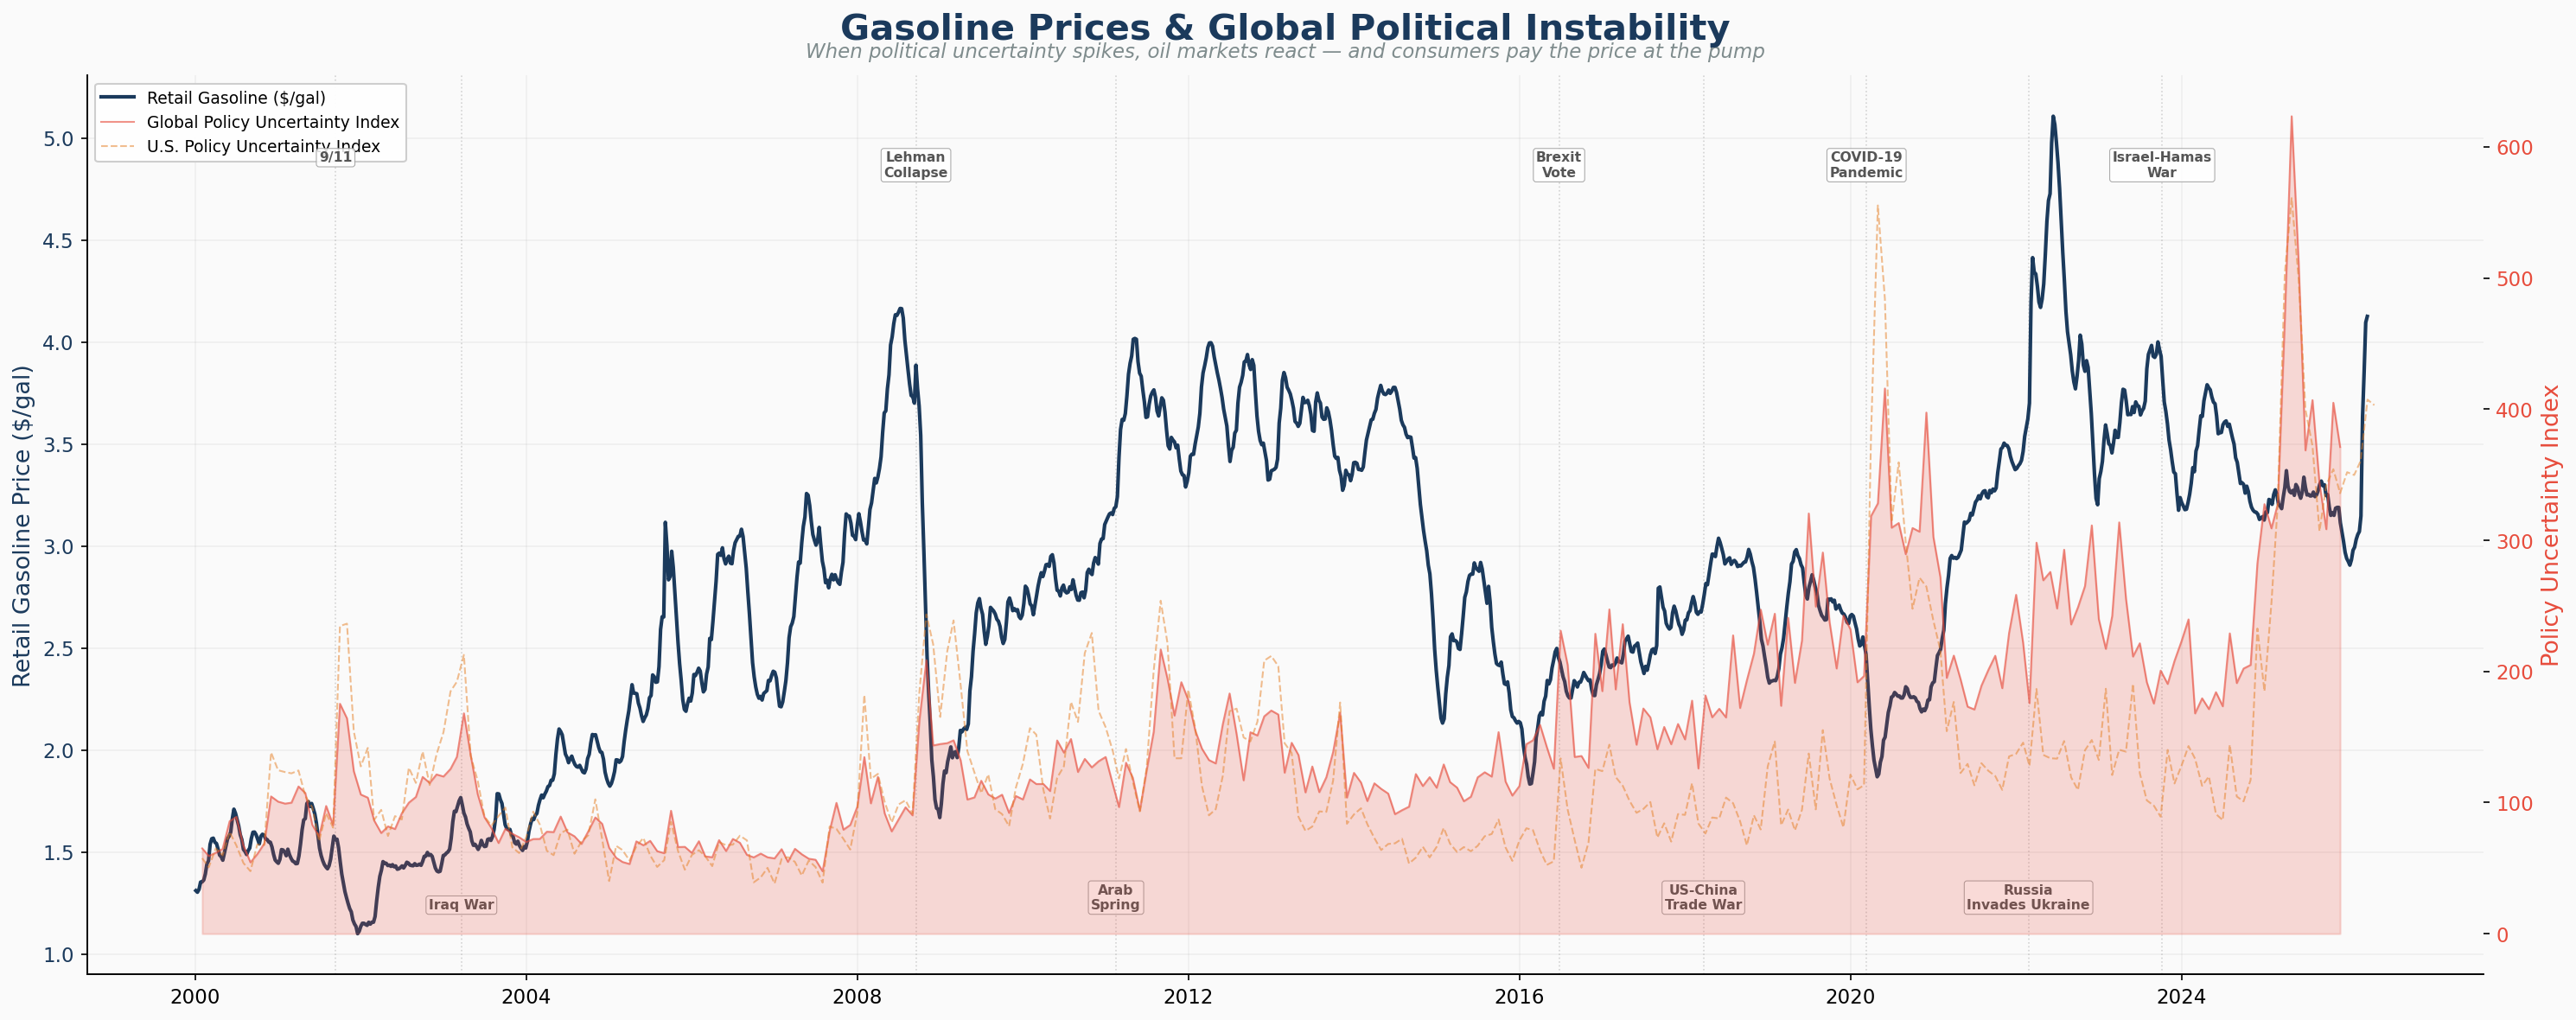


✅ Saved: outputs/geopolitical_uncertainty.png


In [10]:
fig, ax1 = plt.subplots(figsize=(20, 8))
fig.patch.set_facecolor('#FAFAFA')
ax1.set_facecolor('#FAFAFA')
ax1.grid(True, alpha=0.15)

# ---- Retail gasoline price ----
price_col = 'retail_national' if 'retail_national' in master.columns else 'retail_gas_fred'
if price_col in master.columns:
    ax1.plot(master.index, master[price_col], color='#1B3A5C', linewidth=2, 
             label='Retail Gasoline ($/gal)', zorder=3)
ax1.set_ylabel('Retail Gasoline Price ($/gal)', color='#1B3A5C', fontsize=13)
ax1.tick_params(axis='y', labelcolor='#1B3A5C')

# ---- Uncertainty index on secondary axis ----
ax2 = ax1.twinx()

# Use whichever uncertainty series we have
if not gepu.empty:
    gepu_plot = gepu.set_index('date')['GEPUCURRENT']
    # Resample to monthly for smoother line
    gepu_monthly = gepu_plot.resample('M').mean()
    ax2.fill_between(gepu_monthly.index, 0, gepu_monthly.values, 
                     alpha=0.2, color='#E74C3C', zorder=1)
    ax2.plot(gepu_monthly.index, gepu_monthly.values, color='#E74C3C', 
             linewidth=1, alpha=0.6, label='Global Policy Uncertainty Index')

if not uspu.empty:
    uspu_plot = uspu.set_index('date')['USEPUINDXD']
    uspu_monthly = uspu_plot.resample('M').mean()
    ax2.plot(uspu_monthly.index, uspu_monthly.values, color='#E67E22', 
             linewidth=1, alpha=0.5, linestyle='--', label='U.S. Policy Uncertainty Index')

ax2.set_ylabel('Policy Uncertainty Index', color='#E74C3C', fontsize=13)
ax2.tick_params(axis='y', labelcolor='#E74C3C')
ax2.spines['top'].set_visible(False)

# ---- Annotate key geopolitical events ----
geo_events = [
    ('2001-09-11', '9/11'),
    ('2003-03-20', 'Iraq War'),
    ('2008-09-15', 'Lehman\nCollapse'),
    ('2011-02-15', 'Arab\nSpring'),
    ('2016-06-23', 'Brexit\nVote'),
    ('2018-03-22', 'US-China\nTrade War'),
    ('2020-03-11', 'COVID-19\nPandemic'),
    ('2022-02-24', 'Russia\nInvades Ukraine'),
    ('2023-10-07', 'Israel-Hamas\nWar'),
]

for i, (date_str, label) in enumerate(geo_events):
    dt = pd.Timestamp(date_str)
    if dt < master.index.min() or dt > master.index.max():
        continue
    ax1.axvline(dt, color='#999999', alpha=0.4, linewidth=0.8, linestyle=':')
    # Alternate top/bottom
    if i % 2 == 0:
        y_pos = ax1.get_ylim()[1] * 0.93
        va = 'top'
    else:
        y_pos = ax1.get_ylim()[0] + (ax1.get_ylim()[1] - ax1.get_ylim()[0]) * 0.07
        va = 'bottom'
    ax1.annotate(
        label, xy=(dt, y_pos),
        fontsize=7.5, fontweight='bold', color='#555555',
        ha='center', va=va,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, 
                  edgecolor='#999999', linewidth=0.5),
        zorder=10,
    )

# ---- Title & Legend ----
ax1.set_title('Gasoline Prices & Global Political Instability',
              fontsize=20, fontweight='bold', color='#1B3A5C', pad=20)
ax1.text(0.5, 1.02, 
         'When political uncertainty spikes, oil markets react — and consumers pay the price at the pump',
         transform=ax1.transAxes, ha='center', fontsize=11, color='#7F8C8D', fontstyle='italic')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9, framealpha=0.95)

plt.tight_layout()
plt.savefig('outputs/geopolitical_uncertainty.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('\n Saved: outputs/geopolitical_uncertainty.png')

---
## Chart 2: Natural Gas vs Gasoline Prices

Henry Hub natural gas spot price compared to retail gasoline.
Shows where energy markets move together and where they diverge.

In [11]:
# Fetch Henry Hub Natural Gas Spot Price
natgas = fetch_fred('DHHNGSP')

if not natgas.empty:
    print(f'\nNatural Gas: {natgas["date"].min().date()} → {natgas["date"].max().date()}')
    print(f'Price range: ${natgas["DHHNGSP"].min():.2f} – ${natgas["DHHNGSP"].max():.2f} per MMBtu')

  [API] Fetching DHHNGSP... ✅ 6846 rows

Natural Gas: 2000-01-03 → 2026-03-30
Price range: $1.21 – $30.72 per MMBtu


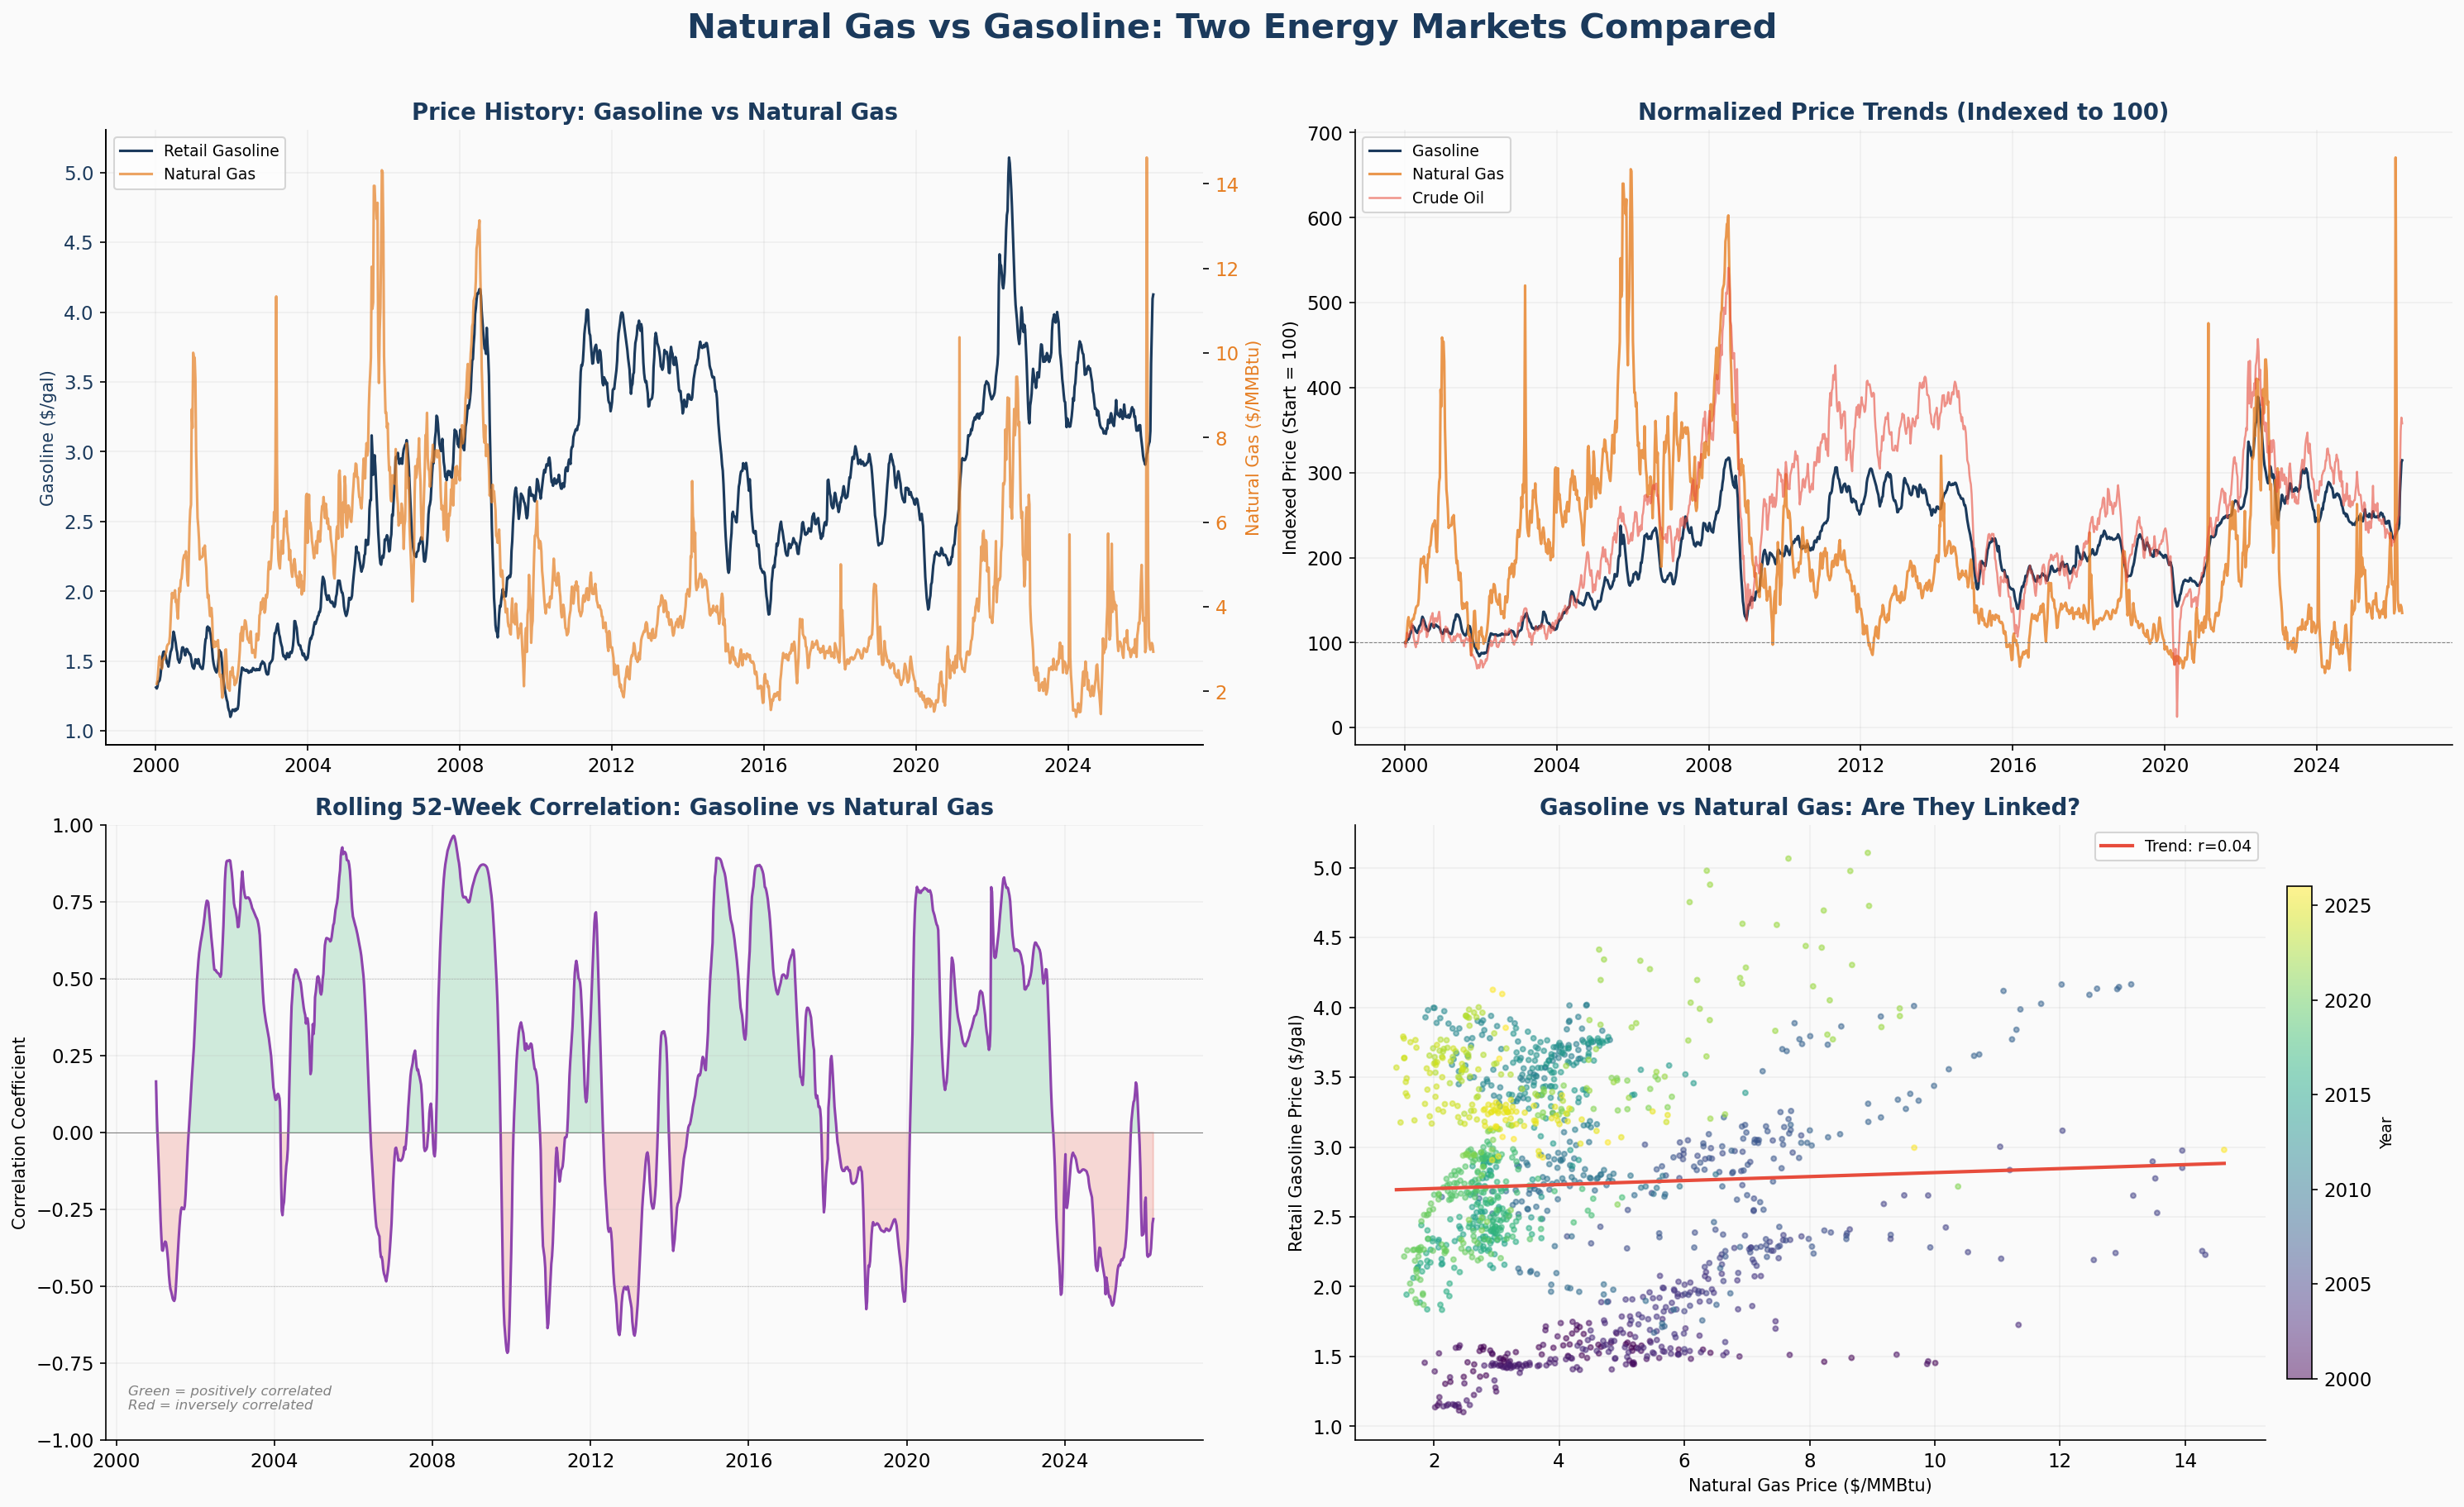


✅ Saved: outputs/natural_gas_comparison.png


In [12]:
if not natgas.empty:
    # Resample natural gas to weekly
    ng = natgas.set_index('date')['DHHNGSP'].resample('W-MON').mean().ffill()
    
    # Get gasoline and crude from master
    price_col = 'retail_national' if 'retail_national' in master.columns else 'retail_gas_fred'
    crude_col = 'wti_crude' if 'wti_crude' in master.columns else 'wti_crude_fred'
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    fig.patch.set_facecolor('#FAFAFA')
    fig.suptitle('Natural Gas vs Gasoline: Two Energy Markets Compared',
                 fontsize=20, fontweight='bold', color='#1B3A5C', y=1.01)
    
    for ax in axes.flat:
        ax.set_facecolor('#FAFAFA')
        ax.grid(True, alpha=0.15)
    
    # ---- Panel 1: Both prices over time (dual axis) ----
    ax = axes[0, 0]
    if price_col in master.columns:
        ax.plot(master.index, master[price_col], color='#1B3A5C', linewidth=1.5, label='Retail Gasoline')
    ax.set_ylabel('Gasoline ($/gal)', color='#1B3A5C', fontsize=10)
    ax.tick_params(axis='y', labelcolor='#1B3A5C')
    
    ax2 = ax.twinx()
    ax2.plot(ng.index, ng.values, color='#E67E22', linewidth=1.5, alpha=0.7, label='Natural Gas')
    ax2.set_ylabel('Natural Gas ($/MMBtu)', color='#E67E22', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='#E67E22')
    ax2.spines['top'].set_visible(False)
    
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    ax.set_title('Price History: Gasoline vs Natural Gas', fontweight='bold', color='#1B3A5C')
    
    # ---- Panel 2: Normalized comparison (base 100) ----
    ax = axes[0, 1]
    
    # Align dates
    common_start = max(master.index.min(), ng.index.min())
    common_end = min(master.index.max(), ng.index.max())
    
    if price_col in master.columns:
        gas_aligned = master.loc[common_start:common_end, price_col].dropna()
        gas_norm = (gas_aligned / gas_aligned.iloc[0]) * 100
        ax.plot(gas_norm.index, gas_norm.values, color='#1B3A5C', linewidth=1.5, label='Gasoline')
    
    ng_aligned = ng.loc[common_start:common_end].dropna()
    ng_norm = (ng_aligned / ng_aligned.iloc[0]) * 100
    ax.plot(ng_norm.index, ng_norm.values, color='#E67E22', linewidth=1.5, alpha=0.8, label='Natural Gas')
    
    if crude_col in master.columns:
        crude_aligned = master.loc[common_start:common_end, crude_col].dropna()
        crude_norm = (crude_aligned / crude_aligned.iloc[0]) * 100
        ax.plot(crude_norm.index, crude_norm.values, color='#E74C3C', linewidth=1.2, alpha=0.6, label='Crude Oil')
    
    ax.axhline(100, color='gray', linewidth=0.5, linestyle='--')
    ax.set_ylabel('Indexed Price (Start = 100)', fontsize=10)
    ax.legend(fontsize=9)
    ax.set_title('Normalized Price Trends (Indexed to 100)', fontweight='bold', color='#1B3A5C')
    
    # ---- Panel 3: Rolling correlation ----
    ax = axes[1, 0]
    
    if price_col in master.columns:
        # Align and calculate rolling correlation
        gas_weekly = master[price_col].dropna()
        common_idx = gas_weekly.index.intersection(ng.index)
        
        if len(common_idx) > 52:
            gas_common = gas_weekly.loc[common_idx]
            ng_common = ng.loc[common_idx]
            
            # 52-week (1-year) rolling correlation
            rolling_corr = gas_common.rolling(52).corr(ng_common)
            
            ax.plot(rolling_corr.index, rolling_corr.values, color='#8E44AD', linewidth=1.5)
            ax.fill_between(rolling_corr.index, 0, rolling_corr.values, 
                          where=rolling_corr.values > 0, alpha=0.2, color='#27AE60')
            ax.fill_between(rolling_corr.index, 0, rolling_corr.values, 
                          where=rolling_corr.values < 0, alpha=0.2, color='#E74C3C')
            ax.axhline(0, color='gray', linewidth=0.5)
            ax.axhline(0.5, color='gray', linewidth=0.3, linestyle='--', alpha=0.5)
            ax.axhline(-0.5, color='gray', linewidth=0.3, linestyle='--', alpha=0.5)
            ax.set_ylim(-1, 1)
    
    ax.set_ylabel('Correlation Coefficient', fontsize=10)
    ax.set_title('Rolling 52-Week Correlation: Gasoline vs Natural Gas', fontweight='bold', color='#1B3A5C')
    ax.text(0.02, 0.05, 'Green = positively correlated\nRed = inversely correlated', 
            transform=ax.transAxes, fontsize=8, color='gray', fontstyle='italic')
    
    # ---- Panel 4: Scatter with trend ----
    ax = axes[1, 1]
    
    if price_col in master.columns and len(common_idx) > 10:
        gas_s = gas_weekly.loc[common_idx].values
        ng_s = ng.loc[common_idx].values
        
        # Remove NaN pairs
        valid = ~(np.isnan(gas_s) | np.isnan(ng_s))
        gas_s = gas_s[valid]
        ng_s = ng_s[valid]
        
        # Color by year for temporal context
        years = common_idx[valid].year
        scatter = ax.scatter(ng_s, gas_s, c=years, cmap='viridis', s=8, alpha=0.5)
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, pad=0.02)
        cbar.set_label('Year', fontsize=9)
        
        # Trend line
        from scipy import stats
        slope, intercept, r, p, se = stats.linregress(ng_s, gas_s)
        x_line = np.linspace(ng_s.min(), ng_s.max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color='#E74C3C', linewidth=2, 
                label=f'Trend: r={r:.2f}')
        ax.legend(fontsize=9)
    
    ax.set_xlabel('Natural Gas Price ($/MMBtu)', fontsize=10)
    ax.set_ylabel('Retail Gasoline Price ($/gal)', fontsize=10)
    ax.set_title('Gasoline vs Natural Gas: Are They Linked?', fontweight='bold', color='#1B3A5C')
    
    plt.tight_layout()
    plt.savefig('outputs/natural_gas_comparison.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
    plt.show()
    print('\n Saved: outputs/natural_gas_comparison.png')
else:
    print(' Could not fetch natural gas data')

## Summary

In [13]:
print('📁 New visualizations saved:')
for name in ['geopolitical_uncertainty.png', 'natural_gas_comparison.png']:
    f = Path(f'outputs/{name}')
    if f.exists():
        size_kb = f.stat().st_size / 1024
        print(f'   {name:<40} {size_kb:.0f} KB')
    else:
        print(f'   {name:<40} NOT FOUND')

print('\n Done! Both charts ready for poster and presentation.')

📁 New visualizations saved:
   geopolitical_uncertainty.png             718 KB
   natural_gas_comparison.png               1239 KB

✅ Done! Both charts ready for poster and presentation.
